# test $M_{\rm surv}$ implementation 

In [1]:
import os
import numpy as np

from sedflow import galaxy as G

In [2]:
# --- plotting --- 
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
gsed = G.ModelB(name='modelb.lowz')

load test data

In [4]:
i = 999
dat_dir = '/tigress/chhahn/sedflow/seds/modelb/'

sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_sps.npz' % i))['arr_0']
tage = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
msurv_nmf = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_nmf.npz.npy' % i))
msurv_burst = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_burst.npz.npy' % i))

## test Msurv

In [5]:
_msurv = gsed._msurv(sps, tage)
_msurv_nmf = gsed._msurv_nmf(sps, tage[:,None])
_msurv_burst = gsed._msurv_burst(sps, tage[:,None])

In [6]:
msurv_true = (1. - sps[:,5]) * msurv_nmf.flatten() + sps[:,5] * msurv_burst.flatten()

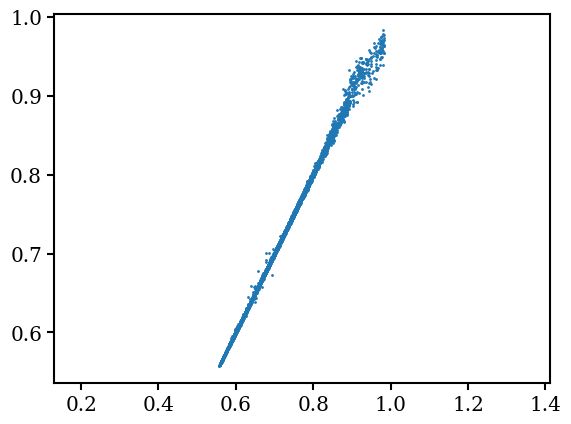

In [7]:
plt.scatter(msurv_nmf, _msurv_nmf, s=1)

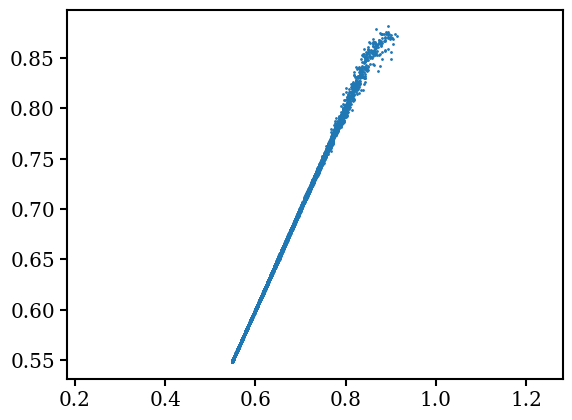

In [8]:
plt.scatter(msurv_burst, _msurv_burst, s=1)

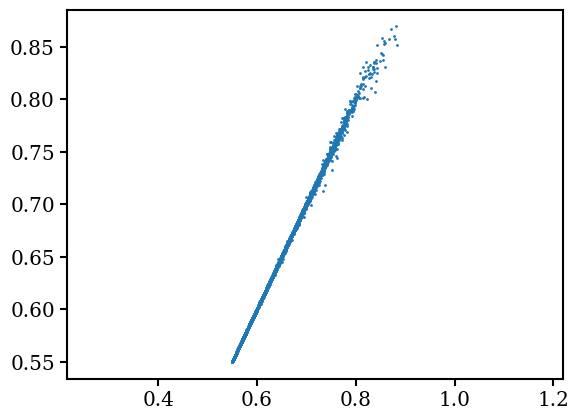

In [9]:
plt.scatter(msurv_true[sps[:,6] < tage], 10**(_msurv-sps[:,0])[sps[:,6] < tage], s=1)

# test SFH

[0.49561441 0.34413351 0.07867995 0.08157213 0.89590364 8.00144906]
9.343551397380141 9.343551397380141
[0.02793038]


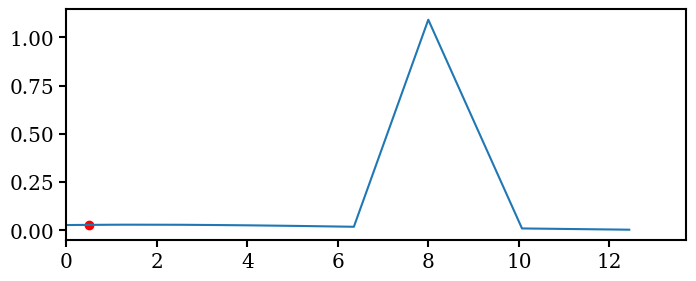

[0.87710041 0.07890122 0.01146172 0.03253665 0.52603487 3.589463  ]
9.022081465584074 9.022081465584074
[0.10794883]


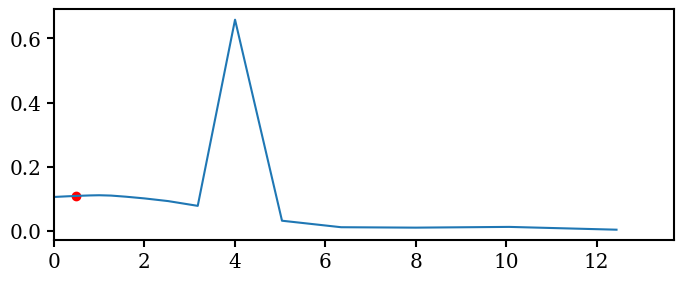

[0.01859634 0.59911168 0.08175132 0.30054065 0.94330488 4.84970232]
7.5665955059242 7.5665955059242
[9.90229567e-06]


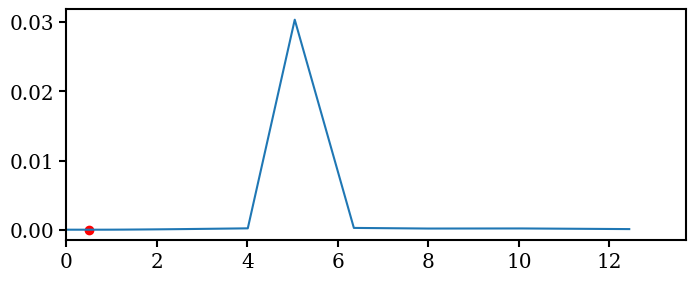

[ 0.68846439  0.16996543  0.03963134  0.10193884  0.76566589 11.49968033]
12.709005482115483 12.709005482115483
[203.13178906]


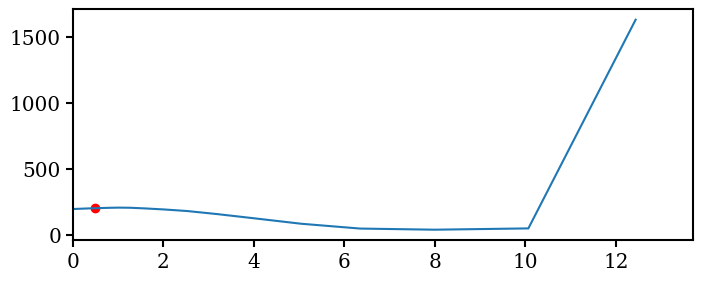

[0.1150278  0.0222916  0.17639058 0.68629002 0.64919062 3.35131953]
12.879866184555233 12.879866184555233
[74.80106008]


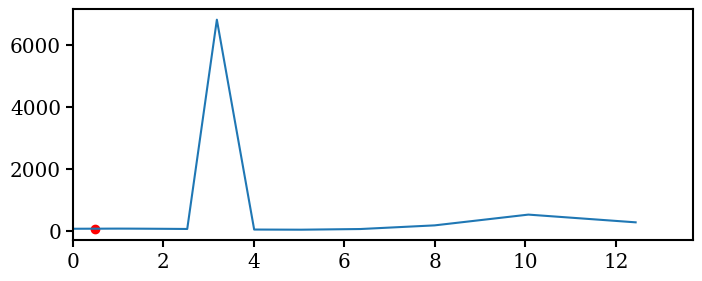

[0.85866336 0.05174221 0.03292507 0.05666936 0.19300066 8.85051773]
7.115788161304449 7.115788161304449
[0.00223201]


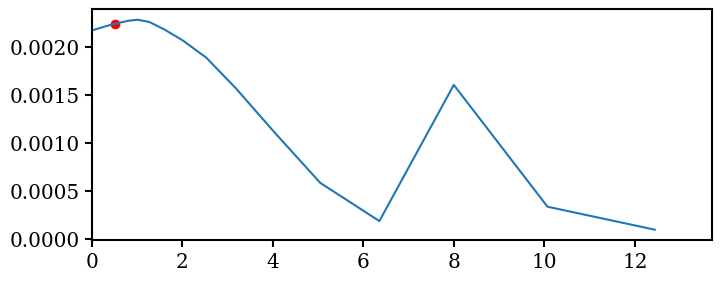

[0.20132313 0.74278934 0.03022505 0.02566249 0.0676825  8.72168309]
8.529710179597187 8.529710179597187
[0.01557621]


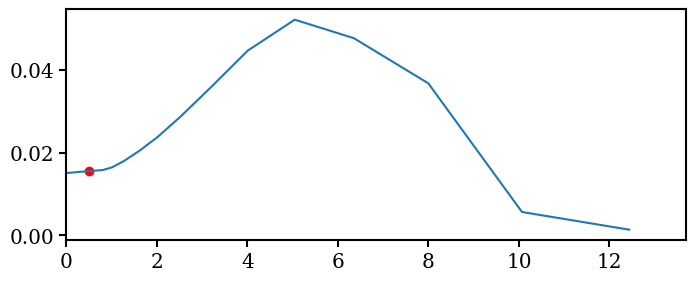

[ 0.64271705  0.21344519  0.07719773  0.06664003  0.90207651 10.15813492]
12.053236038001497 12.053236038001497
[17.49685708]


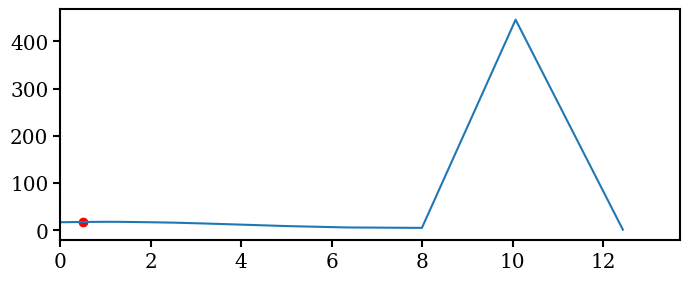

[2.31994640e-01 7.59093126e-01 6.98524167e-03 1.92699195e-03
 5.85684180e-01 8.55299783e+00]
6.769638765657666 6.769638765657666
[0.00013856]


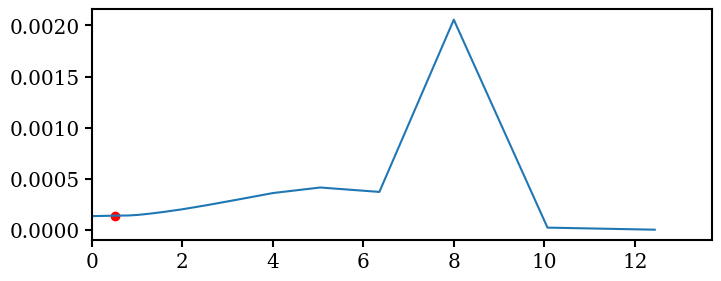

[0.52351473 0.20471149 0.04209191 0.22968187 0.32773184 0.18999278]
9.823432529748434 9.823432529748434
[2.75769627]


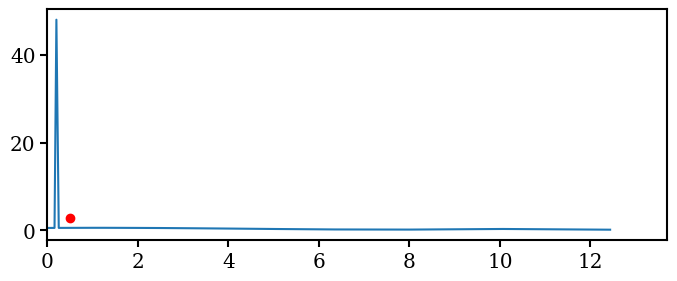

In [18]:
for i in range(10): 
    print(sps[i,1:7])
    _tlb, _sfh = gsed.SFH(sps[i], 0.01)
    print(sps[i,0], np.log10(np.sum(np.diff(_tlb) * _sfh * 1e9)))    
    print(gsed.avgSFR(sps[i], 0.01, dt=1))
    
    fig = plt.figure(figsize=(8,3))
    sub = fig.add_subplot(111)
    sub.plot(0.5*(_tlb[1:] + _tlb[:-1]), _sfh[0])
    sub.scatter([0.5], gsed.avgSFR(sps[i], 0.01, dt=1), c='r')
    sub.set_xlim(0., 13.7)
    plt.show()

# test ZH

[0.00055511 0.0011673 ]
[0.49561441 0.34413351 0.07867995 0.08157213 0.89590364 8.00144906]
[7.65121616] [0.00376583]


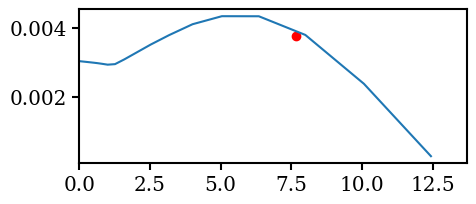

[9.62503199e-05 1.50648434e-03]
[0.87710041 0.07890122 0.01146172 0.03253665 0.52603487 3.589463  ]
[3.56446725] [0.00263349]


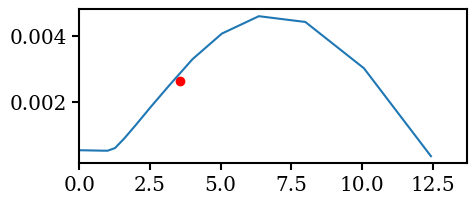

[0.00026482 0.00049521]
[0.01859634 0.59911168 0.08175132 0.30054065 0.94330488 4.84970232]
[5.17089116] [0.00188928]


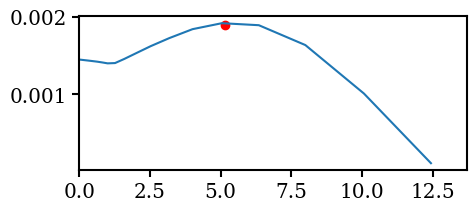

[0.00233093 0.00739932]
[ 0.68846439  0.16996543  0.03963134  0.10193884  0.76566589 11.49968033]
[10.48289451] [0.00529825]


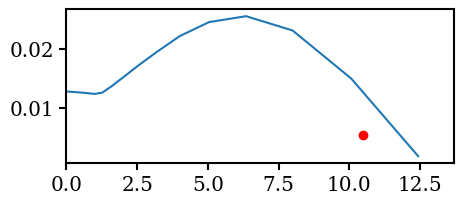

[6.24285231e-03 6.57378707e-05]
[0.1150278  0.0222916  0.17639058 0.68629002 0.64919062 3.35131953]
[5.33568641] [0.01744162]


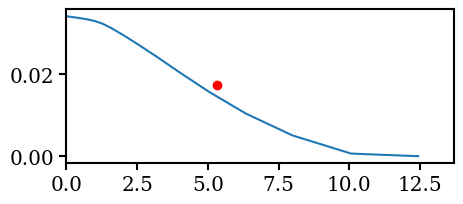

In [10]:
for i in range(5): 
    print(sps[i,7:9])
    _tlb, _zh = gsed.ZH(sps[i], 0.01)
    _zmw = gsed.Z_MW(sps[i], 0.01)
    _tmw = gsed.tage_MW(sps[i], 0.01)
    print(sps[i,1:7])
    print(_tmw, _zmw)
    
    fig = plt.figure(figsize=(5,2))
    sub = fig.add_subplot(111)
    sub.plot(0.5*(_tlb[1:] + _tlb[:-1]), _zh[0])
    sub.scatter([_tmw], [_zmw], c='r')
    sub.set_xlim(0., 13.7)
    plt.show()